In [24]:
import os
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import time
import torchvision.models as models
from matplotlib import pyplot as plt

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')

In [ ]:
device

device(type='cuda')

**Load Dataset**

In [26]:
image_tranform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness = 0.2, contrast = 0.2),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485,0.456,0.406],std= [0.229,0.224,0.225])
])

In [27]:
dataset_path = '/content/drive/MyDrive/Colab Notebooks/Project_Car_Damage_Detection/Download files/dataset'
dataset = datasets.ImageFolder(root = dataset_path, transform = image_tranform)
len(dataset)

2300

In [28]:
class_names = dataset.classes
class_names

['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal']

In [29]:
num_classes = len(dataset.classes)
num_classes

6

In [30]:
train_size = int(0.75*len(dataset))
test_size = len(dataset) - train_size
train_size,test_size

(1725, 575)

In [31]:
from torch.utils.data import random_split

train_dataset,test_dataset = random_split(dataset,[train_size,test_size])

In [32]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = True)

In [33]:
for images, labels in train_loader:
  print(images.shape)
  print(labels.shape)
  break

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [34]:
labels[4]

tensor(4)

In [35]:
images[4].permute(1,2,0).shape

torch.Size([224, 224, 3])

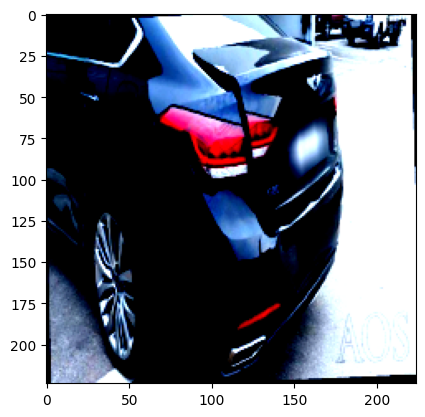

In [36]:
plt.imshow(images[4].permute(1,2,0))
plt.show()

 **Model_1: CNN Model**

In [ ]:
class CarClassifierCNN(nn.Module):
  def __init__(self,num_classes):
    super().__init__()
    self.network = nn.Sequential(
        nn.Conv2d(in_channels = 3,out_channels = 16, kernel_size =3,stride =1,padding = 1), #(16,224,224)
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2 ,stride=2), #(16,112,112)
        nn.Conv2d(in_channels = 16,out_channels = 32, kernel_size =3,stride =1,padding = 1), #(32,112,112)
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2 ,stride=2), #(32,56,56)
        nn.Conv2d(in_channels = 32,out_channels = 64, kernel_size =3,stride =1,padding = 1), #(64,56,56)
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2 ,stride=2), #(64,28,28)
        nn.Flatten(),
        nn.Linear(64*28*28, 512),
        nn.ReLU(),
        nn.Linear(512,num_classes)
    )

  def forward(self,x):
    x = self.network(x)
    return x

In [37]:
def train_model(model,criterion,optimizer,epochs = 5):
  start = time.time()
  for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for batch_num, (images, labels) in enumerate(train_loader):
      images, labels = images.to(device),labels.to(device)

      # Zero the parameters gradients
      optimizer.zero_grad()

      # Forward pass
      outputs = model(images)
      loss = criterion(outputs, labels)

      #Backward pass and optimization
      loss.backward()
      optimizer.step()

      if (batch_num+1) % 10 ==0:
        print(f"Batch: {batch_num+1}, Epoch: {epoch+1}, Loss: {loss.item():0.2f}")

      running_loss = loss.item()* images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch[{epoch+1}/{epochs}], Avg Loss: {epoch_loss:.4f}")

    # Validation
    model.eval()
    correct = 0
    total = 0
    all_labels = []
    all_predictions = []
    with torch.no_grad():
      for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        output = model(images)
        _, predicted = torch.max(output.data,1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())
      print(f"*** Validation Accuracy: {100*correct / total:.2f}% ***")

  end = time.time()
  print(f"Execution Time: {end-start} seconds")
  return all_labels, all_predictions

In [ ]:
# Instantiate the model, loss function, and optimizer
model = CarClassifierCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
all_labels, all_predictions = train_model(model,criterion,optimizer,epochs= 5)

Batch: 10, Epoch: 1, Loss: 1.78
Batch: 20, Epoch: 1, Loss: 1.65
Batch: 30, Epoch: 1, Loss: 1.59
Batch: 40, Epoch: 1, Loss: 1.60
Batch: 50, Epoch: 1, Loss: 1.33
Epoch[1/5], Avg Loss: 0.0209
*** Validation Accuracy: 40.70% ***
Batch: 10, Epoch: 2, Loss: 1.29
Batch: 20, Epoch: 2, Loss: 1.15
Batch: 30, Epoch: 2, Loss: 1.13
Batch: 40, Epoch: 2, Loss: 1.56
Batch: 50, Epoch: 2, Loss: 1.16
Epoch[2/5], Avg Loss: 0.0265
*** Validation Accuracy: 47.83% ***
Batch: 10, Epoch: 3, Loss: 1.23
Batch: 20, Epoch: 3, Loss: 1.48
Batch: 30, Epoch: 3, Loss: 0.97
Batch: 40, Epoch: 3, Loss: 1.18
Batch: 50, Epoch: 3, Loss: 1.32
Epoch[3/5], Avg Loss: 0.0187
*** Validation Accuracy: 49.04% ***
Batch: 10, Epoch: 4, Loss: 1.27
Batch: 20, Epoch: 4, Loss: 1.25
Batch: 30, Epoch: 4, Loss: 1.18
Batch: 40, Epoch: 4, Loss: 1.24
Batch: 50, Epoch: 4, Loss: 1.26
Epoch[4/5], Avg Loss: 0.0244
*** Validation Accuracy: 49.39% ***
Batch: 10, Epoch: 5, Loss: 1.08
Batch: 20, Epoch: 5, Loss: 0.99
Batch: 30, Epoch: 5, Loss: 1.02
Batc

 **Model_2: CNN withRegulariztion**

In [ ]:
class CarClssifierCNNwithRegularization(nn.Module):
  def __init__(self,num_classes):
    super().__init__()
    self.network = nn.Sequential(
        nn.Conv2d(in_channels = 3,out_channels = 16, kernel_size =3,stride =1,padding = 1), #(16,224,224)
        nn.BatchNorm2d(16),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2 ,stride=2), #(16,112,112)
        nn.Conv2d(in_channels = 16,out_channels = 32, kernel_size =3,stride =1,padding = 1), #(32,112,112)
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2 ,stride=2), #(32,56,56)
        nn.Conv2d(in_channels = 32,out_channels = 64, kernel_size =3,stride =1,padding = 1), #(64,56,56)
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2 ,stride=2), #(64,28,28)
        nn.Flatten(),
        nn.Linear(64*28*28, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512,num_classes)
    )

  def forward(self,x):
    x = self.network(x)
    return x

In [ ]:
model = CarClssifierCNNwithRegularization(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001,weight_decay = 0.00001)
train_model(model,criterion,optimizer,epochs=10)

Batch: 10, Epoch: 1, Loss: 12.27
Batch: 20, Epoch: 1, Loss: 4.89
Batch: 30, Epoch: 1, Loss: 2.15
Batch: 40, Epoch: 1, Loss: 1.78
Batch: 50, Epoch: 1, Loss: 1.63
Epoch[1/10], Avg Loss: 0.0347
*** Validation Accuracy: 42.61% ***
Batch: 10, Epoch: 2, Loss: 1.56
Batch: 20, Epoch: 2, Loss: 1.23
Batch: 30, Epoch: 2, Loss: 1.45
Batch: 40, Epoch: 2, Loss: 1.26
Batch: 50, Epoch: 2, Loss: 1.34
Epoch[2/10], Avg Loss: 0.0189
*** Validation Accuracy: 49.04% ***
Batch: 10, Epoch: 3, Loss: 1.10
Batch: 20, Epoch: 3, Loss: 1.41
Batch: 30, Epoch: 3, Loss: 1.23
Batch: 40, Epoch: 3, Loss: 1.43
Batch: 50, Epoch: 3, Loss: 1.12
Epoch[3/10], Avg Loss: 0.0166
*** Validation Accuracy: 51.83% ***
Batch: 10, Epoch: 4, Loss: 1.46
Batch: 20, Epoch: 4, Loss: 1.19
Batch: 30, Epoch: 4, Loss: 1.10
Batch: 40, Epoch: 4, Loss: 1.19
Batch: 50, Epoch: 4, Loss: 0.94
Epoch[4/10], Avg Loss: 0.0143
*** Validation Accuracy: 50.43% ***
Batch: 10, Epoch: 5, Loss: 1.31
Batch: 20, Epoch: 5, Loss: 1.07
Batch: 30, Epoch: 5, Loss: 1.07

([np.int64(3),
  np.int64(1),
  np.int64(0),
  np.int64(1),
  np.int64(4),
  np.int64(0),
  np.int64(5),
  np.int64(5),
  np.int64(0),
  np.int64(0),
  np.int64(3),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(2),
  np.int64(3),
  np.int64(2),
  np.int64(5),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(5),
  np.int64(5),
  np.int64(1),
  np.int64(3),
  np.int64(0),
  np.int64(1),
  np.int64(3),
  np.int64(4),
  np.int64(2),
  np.int64(0),
  np.int64(1),
  np.int64(5),
  np.int64(1),
  np.int64(5),
  np.int64(4),
  np.int64(1),
  np.int64(3),
  np.int64(2),
  np.int64(0),
  np.int64(3),
  np.int64(3),
  np.int64(2),
  np.int64(1),
  np.int64(2),
  np.int64(0),
  np.int64(1),
  np.int64(4),
  np.int64(1),
  np.int64(4),
  np.int64(0),
  np.int64(5),
  np.int64(2),
  np.int64(0),
  np.int64(0),
  np.int64(4),
  np.int64(3),
  np.int64(4),
  np.int64(3),
  np.int64(5),
  np.int64(4),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64

**Model_3: Transfer Learning with EfficentNet**

In [ ]:
class CarClassifierwithEfficentNet(nn.Module):
  def __init__ (self,num_classes):
    super(). __init__()
    self.model = models.efficientnet_b0(weights = 'DEFAULT')

    for param in self.model.parameters():
      param.requires_grad = False

    in_features = self.model.classifier[1].in_features

    self.model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features,num_classes)
    )

  def forward(self,x):
    x = self.model(x)
    return x

In [ ]:
model = CarClassifierwithEfficentNet(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
train_model(model,criterion,optimizer,epochs=10)

Batch: 10, Epoch: 1, Loss: 1.64
Batch: 20, Epoch: 1, Loss: 1.49
Batch: 30, Epoch: 1, Loss: 1.46
Batch: 40, Epoch: 1, Loss: 1.40
Batch: 50, Epoch: 1, Loss: 1.25
Epoch[1/10], Avg Loss: 0.0183
*** Validation Accuracy: 57.04% ***
Batch: 10, Epoch: 2, Loss: 1.22
Batch: 20, Epoch: 2, Loss: 1.24
Batch: 30, Epoch: 2, Loss: 1.16
Batch: 40, Epoch: 2, Loss: 1.06
Batch: 50, Epoch: 2, Loss: 1.20
Epoch[2/10], Avg Loss: 0.0176
*** Validation Accuracy: 62.43% ***
Batch: 10, Epoch: 3, Loss: 1.32
Batch: 20, Epoch: 3, Loss: 1.14
Batch: 30, Epoch: 3, Loss: 0.93
Batch: 40, Epoch: 3, Loss: 1.13
Batch: 50, Epoch: 3, Loss: 1.05
Epoch[3/10], Avg Loss: 0.0179
*** Validation Accuracy: 63.30% ***
Batch: 10, Epoch: 4, Loss: 0.97
Batch: 20, Epoch: 4, Loss: 0.82
Batch: 30, Epoch: 4, Loss: 1.22
Batch: 40, Epoch: 4, Loss: 1.02
Batch: 50, Epoch: 4, Loss: 1.01
Epoch[4/10], Avg Loss: 0.0152
*** Validation Accuracy: 65.91% ***
Batch: 10, Epoch: 5, Loss: 0.90
Batch: 20, Epoch: 5, Loss: 0.93
Batch: 30, Epoch: 5, Loss: 0.83


([np.int64(5),
  np.int64(5),
  np.int64(1),
  np.int64(4),
  np.int64(0),
  np.int64(1),
  np.int64(2),
  np.int64(2),
  np.int64(3),
  np.int64(4),
  np.int64(1),
  np.int64(1),
  np.int64(2),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(2),
  np.int64(0),
  np.int64(5),
  np.int64(3),
  np.int64(4),
  np.int64(5),
  np.int64(5),
  np.int64(5),
  np.int64(2),
  np.int64(2),
  np.int64(1),
  np.int64(0),
  np.int64(4),
  np.int64(0),
  np.int64(5),
  np.int64(3),
  np.int64(0),
  np.int64(2),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(1),
  np.int64(5),
  np.int64(5),
  np.int64(1),
  np.int64(1),
  np.int64(5),
  np.int64(2),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(1),
  np.int64(5),
  np.int64(0),
  np.int64(2),
  np.int64(1),
  np.int64(5),
  np.int64(2),
  np.int64(1),
  np.int64(2),
  np.int64(2),
  np.int64(1),
  np.int64(3),
  np.int64(0),
  np.int64(5),
  np.int64(3),
  np.int64(3),
  np.int64(1),
  np.int64(4),
  np.int64(2),
  np.int64

**Model_4: Transfer Learning with ResNet50**

In [38]:
class CarClassifierwithResNet50(nn.Module):
  def __init__ (self,num_classes,dropout_rate = 0.5):
    super(). __init__()
    self.model = models.resnet50(weights = 'DEFAULT')

    # Freeze all layers except the final fully connected Layer
    for param in self.model.parameters():
      param.requires_grad = False

    # Unfreeze layer4 and fc layers
    for param in self.model.layer4.parameters():
      param.requires_grad = True


    self.model.fc = nn.Sequential(
        nn.Dropout(dropout_rate),
        nn.Linear(self.model.fc.in_features,num_classes)
    )

  def forward(self,x):
    x = self.model(x)
    return x

In [ ]:
model = CarClassifierwithResNet50(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
train_model(model,criterion,optimizer,epochs=10)

Batch: 10, Epoch: 1, Loss: 2.22
Batch: 20, Epoch: 1, Loss: 1.02
Batch: 30, Epoch: 1, Loss: 1.48
Batch: 40, Epoch: 1, Loss: 0.62
Batch: 50, Epoch: 1, Loss: 0.63
Epoch[1/10], Avg Loss: 0.0086
*** Validation Accuracy: 75.83% ***
Batch: 10, Epoch: 2, Loss: 0.65
Batch: 20, Epoch: 2, Loss: 0.31
Batch: 30, Epoch: 2, Loss: 0.45
Batch: 40, Epoch: 2, Loss: 0.44
Batch: 50, Epoch: 2, Loss: 0.36
Epoch[2/10], Avg Loss: 0.0056
*** Validation Accuracy: 78.61% ***
Batch: 10, Epoch: 3, Loss: 0.37
Batch: 20, Epoch: 3, Loss: 0.20
Batch: 30, Epoch: 3, Loss: 0.54
Batch: 40, Epoch: 3, Loss: 0.34
Batch: 50, Epoch: 3, Loss: 0.31
Epoch[3/10], Avg Loss: 0.0032
*** Validation Accuracy: 78.26% ***
Batch: 10, Epoch: 4, Loss: 0.29
Batch: 20, Epoch: 4, Loss: 0.13
Batch: 30, Epoch: 4, Loss: 0.13
Batch: 40, Epoch: 4, Loss: 0.44
Batch: 50, Epoch: 4, Loss: 0.10
Epoch[4/10], Avg Loss: 0.0044
*** Validation Accuracy: 79.65% ***
Batch: 10, Epoch: 5, Loss: 0.12
Batch: 20, Epoch: 5, Loss: 0.14
Batch: 30, Epoch: 5, Loss: 0.29


([np.int64(0),
  np.int64(0),
  np.int64(3),
  np.int64(4),
  np.int64(1),
  np.int64(3),
  np.int64(0),
  np.int64(2),
  np.int64(2),
  np.int64(4),
  np.int64(0),
  np.int64(5),
  np.int64(2),
  np.int64(3),
  np.int64(4),
  np.int64(4),
  np.int64(1),
  np.int64(2),
  np.int64(1),
  np.int64(0),
  np.int64(5),
  np.int64(0),
  np.int64(4),
  np.int64(1),
  np.int64(3),
  np.int64(3),
  np.int64(4),
  np.int64(4),
  np.int64(2),
  np.int64(3),
  np.int64(1),
  np.int64(3),
  np.int64(5),
  np.int64(5),
  np.int64(0),
  np.int64(0),
  np.int64(3),
  np.int64(1),
  np.int64(3),
  np.int64(0),
  np.int64(2),
  np.int64(4),
  np.int64(5),
  np.int64(4),
  np.int64(0),
  np.int64(1),
  np.int64(1),
  np.int64(4),
  np.int64(1),
  np.int64(0),
  np.int64(1),
  np.int64(4),
  np.int64(3),
  np.int64(5),
  np.int64(0),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(3),
  np.int64(0),
  np.int64(0),
  np.int64(4),
  np.int64(2),
  np.int64(4),
  np.int64(1),
  np.int64

#### I ran hyperparameter tunning in another notebook and figured that the best parameters for resnet models are (1) Dropout rate = 0.39960303186323576 (2) Learning Rate = 0.0021461365110921294

So now let's train the model once again with these best parameters

In [39]:
model = CarClassifierwithResNet50(num_classes=num_classes, dropout_rate = 0.39960303186323576).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0021461365110921294)
labels, predictions = train_model(model,criterion,optimizer,epochs=10)

Batch: 10, Epoch: 1, Loss: 0.90
Batch: 20, Epoch: 1, Loss: 0.84
Batch: 30, Epoch: 1, Loss: 0.74
Batch: 40, Epoch: 1, Loss: 0.55
Batch: 50, Epoch: 1, Loss: 0.54
Epoch[1/10], Avg Loss: 0.0078
*** Validation Accuracy: 72.70% ***
Batch: 10, Epoch: 2, Loss: 0.54
Batch: 20, Epoch: 2, Loss: 0.63
Batch: 30, Epoch: 2, Loss: 0.80
Batch: 40, Epoch: 2, Loss: 0.51
Batch: 50, Epoch: 2, Loss: 0.60
Epoch[2/10], Avg Loss: 0.0106
*** Validation Accuracy: 77.74% ***
Batch: 10, Epoch: 3, Loss: 0.18
Batch: 20, Epoch: 3, Loss: 0.31
Batch: 30, Epoch: 3, Loss: 0.42
Batch: 40, Epoch: 3, Loss: 0.44
Batch: 50, Epoch: 3, Loss: 0.17
Epoch[3/10], Avg Loss: 0.0069
*** Validation Accuracy: 80.17% ***
Batch: 10, Epoch: 4, Loss: 0.36
Batch: 20, Epoch: 4, Loss: 0.28
Batch: 30, Epoch: 4, Loss: 0.13
Batch: 40, Epoch: 4, Loss: 0.19
Batch: 50, Epoch: 4, Loss: 0.35
Epoch[4/10], Avg Loss: 0.0071
*** Validation Accuracy: 80.17% ***
Batch: 10, Epoch: 5, Loss: 0.14
Batch: 20, Epoch: 5, Loss: 0.35
Batch: 30, Epoch: 5, Loss: 0.22


### Model Evaluation using Confusion Matrix and Classification Report

In [40]:
from sklearn.metrics import classification_report

report = classification_report(labels, predictions)
print(report)

              precision    recall  f1-score   support

           0       0.81      0.94      0.87       136
           1       0.86      0.66      0.75       101
           2       0.91      0.91      0.91       123
           3       0.69      0.88      0.77        64
           4       0.75      0.64      0.69        66
           5       0.86      0.79      0.82        85

    accuracy                           0.82       575
   macro avg       0.81      0.80      0.80       575
weighted avg       0.83      0.82      0.82       575



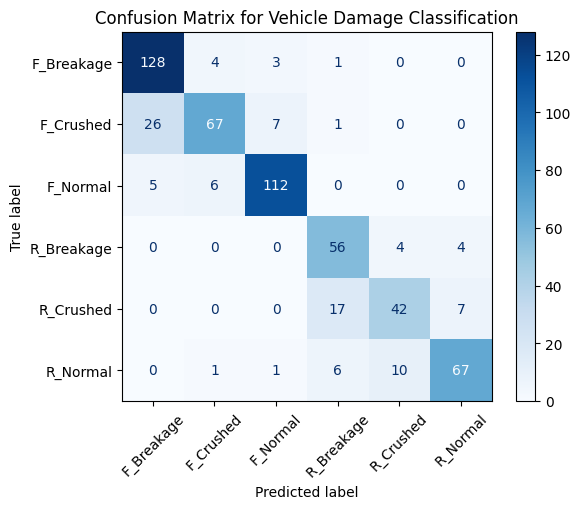

In [41]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt

conf_matrix = confusion_matrix(labels, predictions, labels=np.arange(num_classes))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix for Vehicle Damage Classification")
plt.show()

Save the Model

In [42]:
torch.save(model.state_dict(), 'saved_model.pth')